# Generate the dataset

In [52]:
import random
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device(device)

print(device)

N = 3
N_EXAMPLES=50

cuda


In [53]:
def generate_objects(N=3, block_size=0.2, initial_tower=True):
    # 1. Generate random order for the goals
    idx_goals = [i for i in range(0, N)]
    random.shuffle(idx_goals)

    # 2. Generate initial order for the blocks by inverting the order of goals
    idx_objs = idx_goals[::-1]

    # 3. Generate goals
    # https://www.generationrobots.com/media/panda-franka-emika-datasheet.pdf
    # according to the datasheet, the Franka Panda can reach in an area of 0.855 [m] around itself
    max_reach_dist = 0.7 # [m]

    # select a random (x,y) position for the goal.
    x_goal = random.random() * max_reach_dist
    y_goal = random.random() * max_reach_dist

    pos_goals = [(x_goal, y_goal, i*block_size) for i in range(0, N)]

    # Generate initial positions
    if initial_tower:
        x_obj = random.random() * max_reach_dist
        y_obj = random.random() * max_reach_dist

        pos_objects = [(x_obj, y_obj, i*block_size) for i in range(0, N)]
    else:
        pos_objects = [(random.random() * max_reach_dist, random.random() * max_reach_dist, i*block_size) for i in range(0, N)]

    goals = {}
    objects = {}
    for i in range(0, N):
        goals[idx_goals[i]] = pos_goals[i]
        objects[idx_objs[i]] = pos_objects[i]

    print(f"goals (in desired order of final stacking):\n{goals}")
    print(f"initial object positions (in order of stacking):\n{objects}")

    return objects, goals, idx_objs, idx_goals


In [54]:

# Now solve the stacking problem by taking the highest block in the objects tower (last in order)
# and putting it into the lowest available goal (first in order)


# build the state vector, ordered nodes with categorical, position and binary features, followed by ordered goals with the same features
def build_state(objects, goals):
    s = []
    N = len(objects)
    for n in range(0, N):
        s.append(1) # objects are all blocks
        for o in objects[n]: s.append(o)
        # s.append(objects[n]) # position of block
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    for n in range(0, N):
        s.append(2) # goals
        # s.append(goals[n]) # position of block
        for o in goals[n]: s.append(o)
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    return s

def build_example(N=3, block_size=0.2, initial_tower=True):
    objects, goals, idx_objs, idx_goals = generate_objects(N, block_size, initial_tower)
    
    tau = []    
    tau.append(build_state(objects, goals))

    for n in range(0, N):
        print(f"step #{n}")
        
        o = N-1-n

        print(f"choosing object #{idx_objs[o]} with pos {objects[idx_objs[o]]}")
        print(f"moving object #{idx_objs[o]} to goal{goals[idx_objs[o]]}")

        objects[idx_objs[o]] = goals[idx_objs[o]]
        tau.append([o, o])

        print(f"Updated object positions with goals:")
        print(f"goals:\n{goals}")
        print(f"current objects pos:\n{objects}")
        print("\n")

        tau.append(build_state(objects, goals))

    # TODO (?): add the empty action to a complete graph
    print(tau)
    return tau

In [55]:
# Alternatevely
# at each step, find the highest block that is not yet in its goal
# and move it to the lowest available goal
# repeat until each blocks is in its goal

# Observation to graph

In [56]:
# Now put the demonstration in graph format, using pytorch geometric

import torch
import torch.nn.functional as F
import torch_geometric
from torch_geometric.utils.convert import to_networkx
import networkx as nx

data_list = []
for i in range(N_EXAMPLES):
    print(f"Building example #{i}")
    tau = build_example(N)

    states = tau[0:-1:2] # exclude the complete graph
    actions = tau[1::2]

    print(len(states), states)
    print(len(states), actions)

    # build edges, only once
    # graphs are always fully connected, undirected, and with no edge features
    edges = []
    for i in range(0, N*2):
        for j in range(0, N*2):
            edges.append([i,j])
    print(edges)

    # build nodes and labels
    for n in range(0, N):
        s = states[n]
        a = actions[n]

        # torch_geometric.data.Data is a single graph
        # x is the input graph, as a matrix of dimension [node, node_features]
        # I have N*2 nodes (N blocks, N goals) and 5 features each
        x = torch.reshape(torch.tensor(s), (N*2, -1)) # N*2 considers both goals and blocks
        # y is divided into two vectors, one hot encoded, probabilities for the block and the goal
        y = torch.Tensor.float(F.one_hot(torch.tensor(a), num_classes=N).t())
        y = (y[:, 0].reshape(-1), y[:, 1].reshape(-1))
        G = torch_geometric.data.Data(x=x, edge_index=torch.tensor(edges).t().contiguous(), y=y)

        # save all the graphs into a single data_list for use as a DataLoader later
        data_list.append(G)

    print(data_list)

Building example #0
goals (in desired order of final stacking):
{0: (0.18136575462004528, 0.6242911658347168, 0.0), 1: (0.18136575462004528, 0.6242911658347168, 0.2), 2: (0.18136575462004528, 0.6242911658347168, 0.4)}
initial object positions (in order of stacking):
{2: (0.2066231418264936, 0.31231730662019885, 0.0), 1: (0.2066231418264936, 0.31231730662019885, 0.2), 0: (0.2066231418264936, 0.31231730662019885, 0.4)}
step #0
choosing object #0 with pos (0.2066231418264936, 0.31231730662019885, 0.4)
moving object #0 to goal(0.18136575462004528, 0.6242911658347168, 0.0)
Updated object positions with goals:
goals:
{0: (0.18136575462004528, 0.6242911658347168, 0.0), 1: (0.18136575462004528, 0.6242911658347168, 0.2), 2: (0.18136575462004528, 0.6242911658347168, 0.4)}
current objects pos:
{2: (0.2066231418264936, 0.31231730662019885, 0.0), 1: (0.2066231418264936, 0.31231730662019885, 0.2), 0: (0.18136575462004528, 0.6242911658347168, 0.0)}


step #1
choosing object #1 with pos (0.20662314182

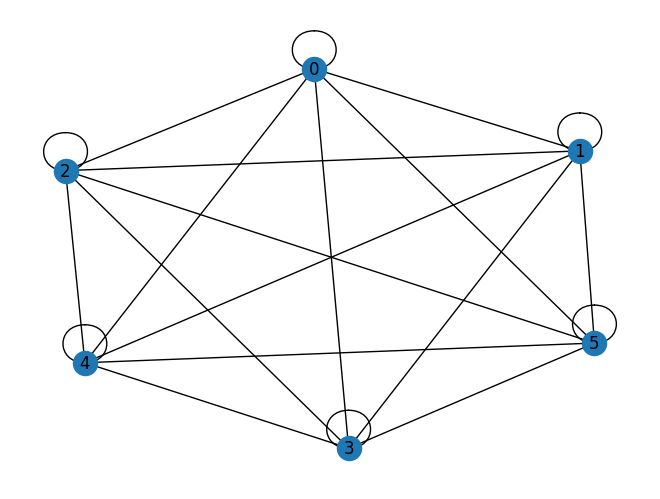

In [57]:
g = torch_geometric.utils.to_networkx(G, to_undirected=True)
nx.draw(g, with_labels=True)

# Build torch_geometric dataset from examples

In [58]:
# https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_dataset.html#frequently-asked-questions
# just create a DataLoader starting from the list of example Data
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=1)

# Build NN

In [59]:
# https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html
# https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html

import torch
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # All policies consist of 3 hidden layers, with 64 hidden units each and ReLU activation.
        # For attention policies, the number of attention heads were set to 1.
        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)

        # print("pre softmax ", x)

        # The output of the GNN policy is K + L dimensional, reshaped into K and L dimensional outputs
        objects = x[:N, :].reshape(-1)
        goals = x[N:, :].reshape(-1)

        # print("slice")
        # print()
        # print(objects, goals)

        # and is then passed through a softmax function to generate a K-dimensional cateagorial distribution
        # depicting the picking probabilities of objects. 
        # The object with the highest predicted probability is the output of the GNN
        return (F.softmax(objects, dim=0), F.softmax(goals, dim=0))


model = GCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
model.train()

running_loss = 0.
last_loss = 0.

n_epochs = 1000

for epoch in range(n_epochs):
    # index and do some intra-epoch reporting
    for i, data in enumerate(loader):
        # Every data instance is an input + label pair
        # print(data)

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        out = model(data)

        # print("labels")
        # print(data.y)
        # print("prediction")
        # print(out)

        # Compute the loss and its gradients
        # error in taking this splice with batch_size > 1
        l1 = F.cross_entropy(out[0], data.y[0])
        # print("l1", out[0], data.y[0])
        l2 = F.cross_entropy(out[1], data.y[1])
        # print("l2", out[1], data.y[1])
        loss = l1 + l2
        loss.backward()

        # print("loss", l1, l2, loss)

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()

    print(running_loss)
    running_loss = 0.

329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592
329.5836925506592


KeyboardInterrupt: 